## Loading and Preprocessing Data

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahulsah06/gooogle-stock-price")

print("Path to dataset files:", path)

100%|██████████| 23.4k/23.4k [00:00<00:00, 822kB/s]

Extracting files...
Path to dataset files: C:\Users\mithsuka.dikkumbura\.cache\kagglehub\datasets\rahulsah06\gooogle-stock-price\versions\1


In [3]:
# Importing the training set
dataset_train = pd.read_csv(path+"/Google_Stock_Price_Train.csv")

In [4]:
dataset_train.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [5]:
"Extracting only the Open price. Converting to a NumPy array. Shape becomes (number_of_days, 1)"
train = dataset_train.loc[:, ["Open"]].values
train

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]], shape=(1258, 1))

In [6]:
# Feature Scaling
"RNNs work better when inputs are in a small numerical range. Stock prices vary widely → scaling stabilizes training. Scales values to [0, 1]. "
"fit_transform learns min/max from training data and scales it"

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
train_scaled = scaler.fit_transform(train)
train_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]], shape=(1258, 1))

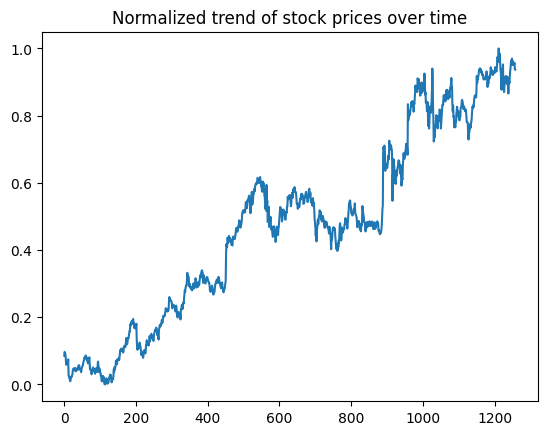

In [7]:
plt.plot(train_scaled)
plt.title("Normalized trend of stock prices over time")
plt.show()

In [8]:
# Creating a data structure with 50 timesteps and 1 output
X_train = []
y_train = []
timesteps = 50 # Each prediction uses the previous 50 days to predict the next day

for i in range(timesteps, 1258):
    X_train.append(train_scaled[i-timesteps:i, 0]) # sequences of 50 previous stock prices
    y_train.append(train_scaled[i, 0])             # the stock price immediately after those 50 days

X_train, y_train = np.array(X_train), np.array(y_train)

In [9]:
# Reshaping (for RNN input)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train # is in shape of (samples, timesteps, features) -> (number of training examples, 50, 1 feature=open price)

array([[[0.08581368],
        [0.09701243],
        [0.09433366],
        ...,
        [0.03675869],
        [0.04486941],
        [0.05065481]],

       [[0.09701243],
        [0.09433366],
        [0.09156187],
        ...,
        [0.04486941],
        [0.05065481],
        [0.05214302]],

       [[0.09433366],
        [0.09156187],
        [0.07984225],
        ...,
        [0.05065481],
        [0.05214302],
        [0.05612397]],

       ...,

       [[0.9313937 ],
        [0.94636878],
        [0.96569685],
        ...,
        [0.95475854],
        [0.95204256],
        [0.95163331]],

       [[0.94636878],
        [0.96569685],
        [0.97510976],
        ...,
        [0.95204256],
        [0.95163331],
        [0.95725128]],

       [[0.96569685],
        [0.97510976],
        [0.95966962],
        ...,
        [0.95163331],
        [0.95725128],
        [0.93796041]]], shape=(1208, 50, 1))

In [10]:
y_train

array([0.05214302, 0.05612397, 0.05818885, ..., 0.95725128, 0.93796041,
       0.93688146], shape=(1208,))

## Create RNN Model

In [11]:
# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout


# Initialising the RNN
regressor = Sequential()

# 1st RNN layer with some Dropout regularisation
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# 2nd RNN layer with some Dropout regularisation. Units = neurons. return_sequences needed as another RNN follows
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# 3rd RNN layer with some Dropout regularisation. Deep RNN structure improves pattern learning over time
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# A final 4th RNN layer with some Dropout regularisation. return_sequences is false as outputs only the last timestep
regressor.add(SimpleRNN(units = 50))
regressor.add(Dropout(0.2))

# Output layer - predicts next day's stock price
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
regressor.fit(X_train, y_train, epochs = 100, batch_size = 32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.4425
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3069
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2402
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1959
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1274
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0943
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0772
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0637
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0562
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0461
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0420
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0386
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0353
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0309
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - lo

## Predictions and Visualising RNN Model

In [12]:
# Getting the real stock price of 2017
dataset_test = pd.read_csv(path+'/Google_Stock_Price_Test.csv')
dataset_test.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [13]:
# Ground truth for comparison
real_stock_price = dataset_test.loc[:, ["Open"]].values
real_stock_price

array([[778.81],
       [788.36],
       [786.08],
       [795.26],
       [806.4 ],
       [807.86],
       [805.  ],
       [807.14],
       [807.48],
       [807.08],
       [805.81],
       [805.12],
       [806.91],
       [807.25],
       [822.3 ],
       [829.62],
       [837.81],
       [834.71],
       [814.66],
       [796.86]])

In [14]:
# Getting the predicted stock price of 2017. 
"Predictions for day t need the previous 50 days. Some of those days come from training data"

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - timesteps:].values.reshape(-1,1)
inputs = scaler.transform(inputs)  # min max scaler
inputs


array([[0.97510976],
       [0.95966962],
       [0.97808617],
       [1.        ],
       [0.98076494],
       [0.97083116],
       [0.98450406],
       [0.96054394],
       [0.9371419 ],
       [0.92841729],
       [0.90804747],
       [0.8771858 ],
       [0.92153434],
       [0.93809063],
       [0.93165414],
       [0.95254483],
       [0.88812412],
       [0.88637547],
       [0.87032145],
       [0.88563137],
       [0.90743359],
       [0.91571173],
       [0.89941588],
       [0.91805566],
       [0.9089404 ],
       [0.9024853 ],
       [0.89456061],
       [0.91600938],
       [0.9132934 ],
       [0.88979835],
       [0.86589404],
       [0.89030062],
       [0.90335962],
       [0.89642086],
       [0.91777662],
       [0.93176576],
       [0.94114145],
       [0.95762334],
       [0.96413424],
       [0.96402262],
       [0.96971501],
       [0.95077759],
       [0.96294367],
       [0.96123223],
       [0.95475854],
       [0.95204256],
       [0.95163331],
       [0.957

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


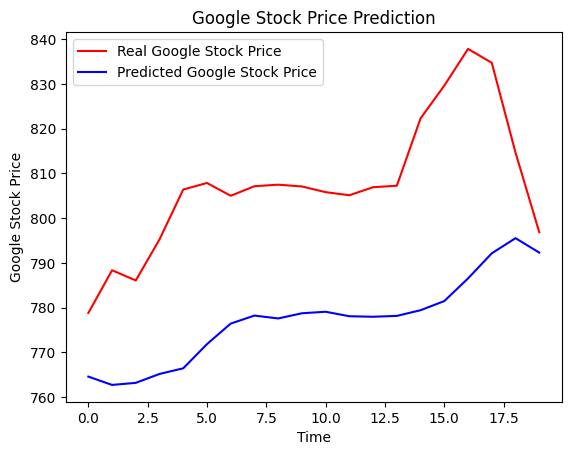

In [15]:
# Creates sliding windows just like training data. 70 corresponds to number of test days.
X_test = []
for i in range(timesteps, 70):
    X_test.append(inputs[i-timesteps:i, 0])

# Reshaped for RNN input. 
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)

# Predictions are scaled back to original price values
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)


# Visualising the results -> how well the model follows the real trend?
plt.plot(real_stock_price, color = 'red', label = 'Real Google Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()


## Assignment
Try to improve the result! Document your actions and conclusions further in this notebook.

#### License
This Notebook has been released under the Apache 2.0 open source license.

https://www.kaggle.com/code/moonglow22/rnn-and-lstm-tutorial-for-beginners/notebook

In [18]:
baseline_rmse = np.sqrt(mean_squared_error(real_stock_price[:, 0], predicted_stock_price[:, 0]))
print("Baseline Test RMSE:", round(baseline_rmse, 4))

Baseline Test RMSE: 32.1212


Calculated the baseline RMSE using the model prediction
Lower RMSE means the prediction is closer to the real stock price.

In [19]:
def make_train_sequences(train_scaled_data, timesteps_local):
    X, y = [], []
    for i in range(timesteps_local, len(train_scaled_data)):
        X.append(train_scaled_data[i - timesteps_local:i, 0])
        y.append(train_scaled_data[i, 0])
    X = np.array(X).reshape(-1, timesteps_local, 1)
    y = np.array(y)
    return X, y

def make_test_sequences(dataset_train_df, dataset_test_df, timesteps_local, scaler_local):
    dataset_total_local = pd.concat((dataset_train_df['Open'], dataset_test_df['Open']), axis=0)
    inputs_local = dataset_total_local[len(dataset_total_local) - len(dataset_test_df) - timesteps_local:].values.reshape(-1, 1)
    inputs_local = scaler_local.transform(inputs_local)

    X_test_local = []
    for i in range(timesteps_local, len(dataset_test_df) + timesteps_local):
        X_test_local.append(inputs_local[i - timesteps_local:i, 0])

    X_test_local = np.array(X_test_local).reshape(-1, timesteps_local, 1)
    return X_test_local

def rmse_on_test(model_local, X_test_local, real_stock_price_local, scaler_local):
    pred_scaled = model_local.predict(X_test_local, verbose=0)
    pred_real = scaler_local.inverse_transform(pred_scaled)
    rmse = np.sqrt(mean_squared_error(real_stock_price_local[:, 0], pred_real[:, 0]))
    return rmse, pred_real

Made small helper functions so I can test different settings (like timesteps, dropout)

In [20]:
try:
    Dropout
except NameError:
    from keras.layers import Dropout

timesteps_imp1 = 60

X_train_imp1, y_train_imp1 = make_train_sequences(train_scaled, timesteps_imp1)
X_test_imp1 = make_test_sequences(dataset_train, dataset_test, timesteps_imp1, scaler)

model_imp1 = Sequential()
model_imp1.add(SimpleRNN(units=80, activation='tanh', return_sequences=True, input_shape=(timesteps_imp1, 1)))
model_imp1.add(Dropout(0.2))
model_imp1.add(SimpleRNN(units=80, activation='tanh'))
model_imp1.add(Dropout(0.2))
model_imp1.add(Dense(1))

model_imp1.compile(optimizer='adam', loss='mean_squared_error')
model_imp1.fit(X_train_imp1, y_train_imp1, epochs=60, batch_size=32, verbose=0)

rmse_imp1, pred_imp1 = rmse_on_test(model_imp1, X_test_imp1, real_stock_price, scaler)
print("Improvement 1 Test RMSE:", round(rmse_imp1, 4))

Improvement 1 Test RMSE: 10.752


Increased timesteps to 60 so the model sees more previous days before predicting
Increased units to 80 to let the model learn more patterns
I compare the RMSE with the baseline to see if it improved

In [21]:
try:
    Dropout
except NameError:
    from keras.layers import Dropout

timesteps_imp2 = 50

X_train_imp2, y_train_imp2 = make_train_sequences(train_scaled, timesteps_imp2)
X_test_imp2 = make_test_sequences(dataset_train, dataset_test, timesteps_imp2, scaler)

model_imp2 = Sequential()
model_imp2.add(SimpleRNN(units=50, activation='tanh', return_sequences=True, input_shape=(timesteps_imp2, 1)))
model_imp2.add(Dropout(0.35))
model_imp2.add(SimpleRNN(units=50, activation='tanh'))
model_imp2.add(Dropout(0.35))
model_imp2.add(Dense(1))

model_imp2.compile(optimizer='adam', loss='mean_squared_error')
model_imp2.fit(X_train_imp2, y_train_imp2, epochs=60, batch_size=32, verbose=0)

rmse_imp2, pred_imp2 = rmse_on_test(model_imp2, X_test_imp2, real_stock_price, scaler)
print("Improvement 2 Test RMSE:", round(rmse_imp2, 4))

Improvement 2 Test RMSE: 11.2404


Increased Dropout to 0.35 to reduce memorizing the training data 
If RMSE goes down, dropout helped. If RMSE goes up, dropout was probably too strong.

Baseline RMSE: 32.1212
Best model: Improvement 1
Best RMSE: 10.752


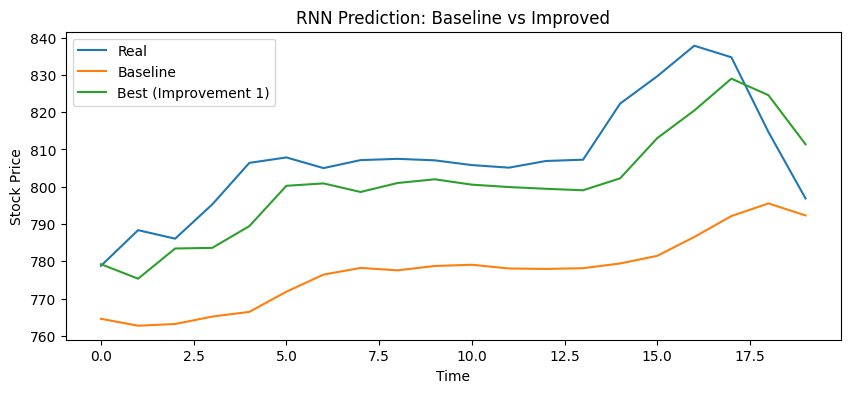

In [22]:
best_name = "Improvement 1" if rmse_imp1 <= rmse_imp2 else "Improvement 2"
best_rmse = rmse_imp1 if rmse_imp1 <= rmse_imp2 else rmse_imp2
best_pred = pred_imp1 if rmse_imp1 <= rmse_imp2 else pred_imp2

print("Baseline RMSE:", round(baseline_rmse, 4))
print("Best model:", best_name)
print("Best RMSE:", round(best_rmse, 4))

plt.figure(figsize=(10, 4))
plt.plot(real_stock_price, label="Real")
plt.plot(predicted_stock_price, label="Baseline")
plt.plot(best_pred, label=f"Best ({best_name})")
plt.title("RNN Prediction: Baseline vs Improved")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

Picked the model with the lowest RMSE and plotted it with the real value
The better model is the one that stays closer to the real curve and has a lower RMSE than baseline.

Conclusion

Tested with different model settings and compared the RMSE results
The best model was the one with the lowest error
This shows that adjusting parameters can improve prediction performance